In [9]:
"""
Import required libraries
"""

%load_ext autoreload
%autoreload 2

import sys
import os

sys.path.append(os.path.abspath(os.path.join("..")))

import numpy as np

from src.util import *
from src.benchmark_ssm.hi_smc import *
from src.benchmark_ssm.pf import *
from src.benchmark_ssm.ssm import *
from src.benchmark_ssm.mh import *
from src.linear_ssm.hi_smc import *
from src.linear_ssm.pf import *
from src.linear_ssm.ssm import *
from src.linear_ssm.mh import *
from src.nonlinear_ssm.hi_smc import *
from src.nonlinear_ssm.pf import *
from src.nonlinear_ssm.ssm import *
from src.nonlinear_ssm.mh import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


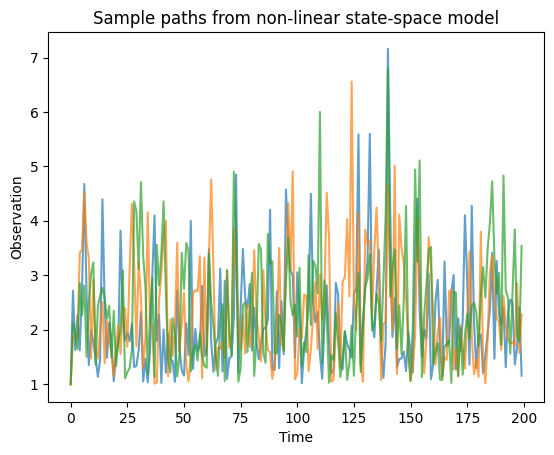

In [2]:
"""
Non-linear state-space model test / debug run
"""

T = 200
rng = np.random.default_rng(seed=42)
u = rng.normal(loc=0, scale=1, size=T)
theta = np.asarray([1,1])

n_paths = 3

for _ in range(n_paths):
    xs, ys = Svensson2017NonLinearSSM_simulate(u, theta, T, rng)
    plt.plot(ys, alpha=0.7)
    

plt.title("Sample paths from non-linear state-space model")
plt.xlabel("Time")
plt.ylabel("Observation")
plt.show()

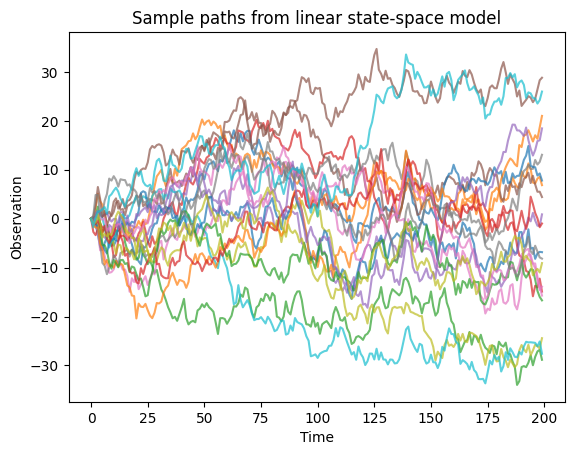

In [3]:
"""
Linear state-space model test / debug run
"""

T = 200
rng = np.random.default_rng(seed=42)
u = rng.normal(loc=0, scale=1, size=T)
theta = np.asarray([-1, 0.8])

n_paths = 20

for _ in range(n_paths):
    xs, ys = Svensson2017LinearSSM_simulate(u, theta, T, rng)
    plt.plot(ys, alpha=0.7)
    

plt.title("Sample paths from linear state-space model")
plt.xlabel("Time")
plt.ylabel("Observation")
plt.show()

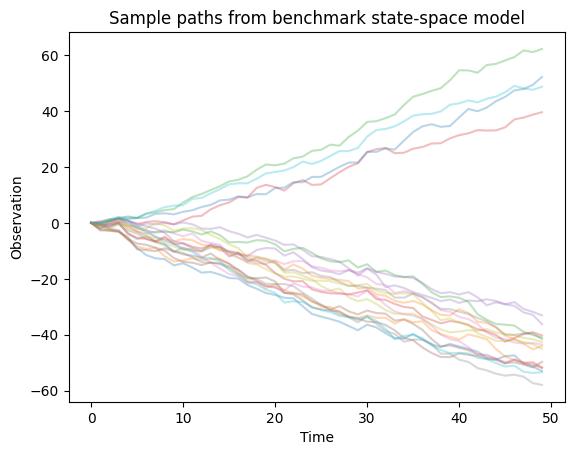

In [3]:
"""
Benchmark state-space model test / debug run
"""

T = 50
rng = np.random.default_rng(seed=42)
u = rng.normal(loc=0, scale=1, size=T)
theta = np.asarray(1)

n_paths = 20

for _ in range(n_paths):
    xs, ys = SimpleBenchmarkSSM_simulate(us=u, theta=theta, T=T, rng=rng)
    plt.plot(ys, alpha=0.3)
    

plt.title("Sample paths from benchmark state-space model")
plt.xlabel("Time")
plt.ylabel("Observation")
plt.show()

Particle filter took 0.0036013126373291016s
PMMH took 1.0536105632781982s
Acceptance rate of initial PMMH sample: 0.8766666666666667


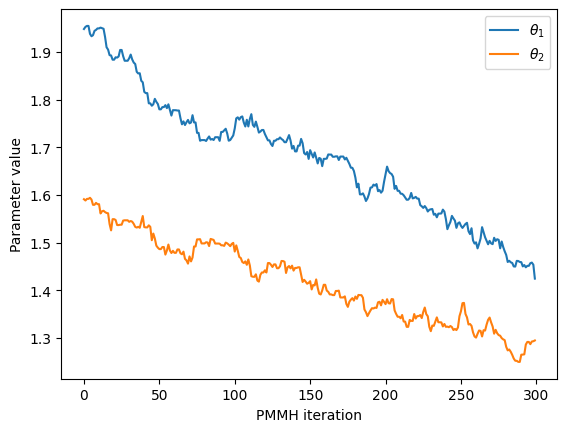

In [ ]:
"""
PMMH test / debug run for nonlinear model
"""

""" Test whether the PMH sampling works by sampling
an intiial estimate from the posterior p(theta|y_1:T,temp)
"""

temp = 10 # Initial tempering
T = 100 # Number of observations

# True parameter
theta = np.asarray([1,1])

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
_, ys = Svensson2017NonLinearSSM_simulate(theta=theta,T=T,u=u,rng=rng)

# Sample theta from parameter prior
theta = Svensson2017NonLinearSSM_sample_prior()

# Generate particle approximations for p(y_t|x_1:T,theta,temp)
# for the initial parameter sample
t0 = time.time()
xs, aas, log_lik = Svensson2017NonLinearSSM_bootstrap_pf(temp=temp,
                          n_particles=300,
                          ys=ys,
                          us=us,
                          theta=theta,
                          alternative_tempering=False
                          )
t1 = time.time()
print(f'Particle filter took {t1 - t0}s')

# Run PMH
t0 = time.time()

samples, xss, aass, log_liks, accept_rate = Svensson2017NonLinearSSM_pmmh(
    xs=xs,
    aas=aas,
    log_lik=log_lik,
    theta=theta,
    ys=ys,
    us=us,
    temp=temp,
    n_iters=300,
    proposal_sd=0.01,
    verbose=True,
    alternative_tempering=False
)
t1 = time.time()
print(f'PMMH took {t1 - t0}s')
print(f'Acceptance rate of initial PMMH sample: {accept_rate}')

# Plot result
plt.plot(samples[:,0],label=r'$\theta_1$')
plt.plot(samples[:,1],label=r'$\theta_2$')
plt.xlabel('PMMH iteration')
plt.ylabel('Parameter value')
plt.legend()

Starting Metropolis-Hastings run
                 Parameters: 
                 initial position = [ 0.25008151 -0.45376311]
                 tempering        = 1
                 iterations       = 300
                 proposal_sd      = 0.4
Finished Metropolis-Hastings run 
                 Acceptance rate: 0.20666666666666667
MH took 315.91270184516907s
Acceptance rate of initial MH sample: 0.9733333333333334


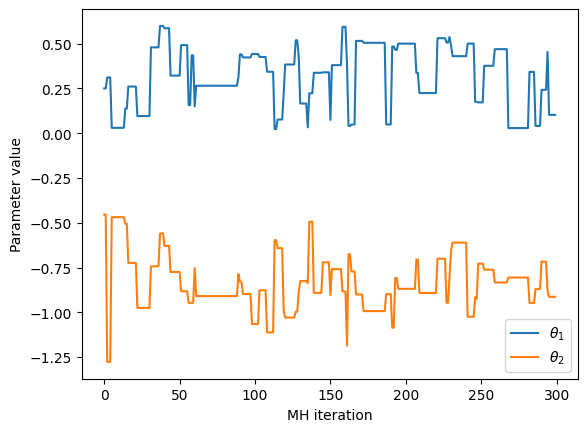

In [28]:
"""
MH test / debug run for linear model
"""

""" Test whether the MH sampling works by sampling
an intiial estimate from the posterior p(theta|y_1:T,temp)
"""

temp = 1 # Initial tempering
T = 200 # Number of observations

# True parameter
theta = np.asarray([-1,0.8])

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
_, ys = Svensson2017LinearSSM_simulate(theta=theta,T=T,u=us,rng=rng)

# Sample theta from parameter prior
theta = Svensson2017LinearSSM_sample_prior()

samples = Svensson2017LinearSSM_mh(
    initial_theta=theta,
    ys=ys,
    us=us,
    temp=temp,
    n_iters=300,
    proposal_sd=0.4,
    verbose=True
)
t1 = time.time()
print(f'MH took {t1 - t0}s')
print(f'Acceptance rate of initial MH sample: {accept_rate}')

# Plot result
plt.plot(samples[:,0],label=r'$\theta_1$')
plt.plot(samples[:,1],label=r'$\theta_2$')
plt.xlabel('MH iteration')
plt.ylabel('Parameter value')
plt.legend()

Particle filter took 0.018809795379638672s
PMMH took 5.456845998764038s
Acceptance rate of initial PMMH sample: 0.5133333333333333


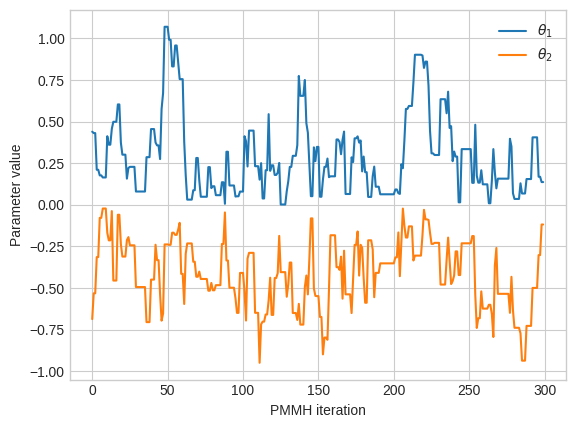

In [34]:
"""
PMMH test / debug run for linear model
"""

""" Test whether the PMMH sampling works by sampling
an intiial estimate from the posterior p(theta|y_1:T,temp)
"""

temp = 10 # Initial tempering
T = 100 # Number of observations

# True parameter
theta = np.asarray([0.8,-1])

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
_, ys = Svensson2017LinearSSM_simulate(theta=theta,T=T,u=us,rng=rng)

# Sample theta from parameter prior
theta = Svensson2017LinearSSM_sample_prior()

# Generate particle approximations for p(y_t|x_1:T,theta,temp)
# for the initial parameter sample
t0 = time.time()
xs, aas, log_lik = Svensson2017LinearSSM_bootstrap_pf(temp=temp,
                          n_particles=300,
                          ys=ys,
                          us=us,
                          theta=theta,
                          alternative_tempering=False
                          )
t1 = time.time()
print(f'Particle filter took {t1 - t0}s')

# Run PMH
t0 = time.time()

samples, xss, aass, log_liks, accept_rate = Svensson2017LinearSSM_pmmh(
    xs=xs,
    aas=aas,
    log_lik=log_lik,
    theta=theta,
    ys=ys,
    us=us,
    temp=temp,
    n_iters=300,
    proposal_sd=0.2,
    verbose=True,
    alternative_tempering=False
)
t1 = time.time()
print(f'PMMH took {t1 - t0}s')
print(f'Acceptance rate of initial PMMH sample: {accept_rate}')

# Plot result
plt.plot(samples[:,0],label=r'$\theta_1$')
plt.plot(samples[:,1],label=r'$\theta_2$')
plt.xlabel('PMMH iteration')
plt.ylabel('Parameter value')
plt.legend()

Particle filter took 0.0004241466522216797s
PMMH took 0.11571192741394043s
Acceptance rate of initial PMMH sample: 0.016, sd: 0.03, particles: 50


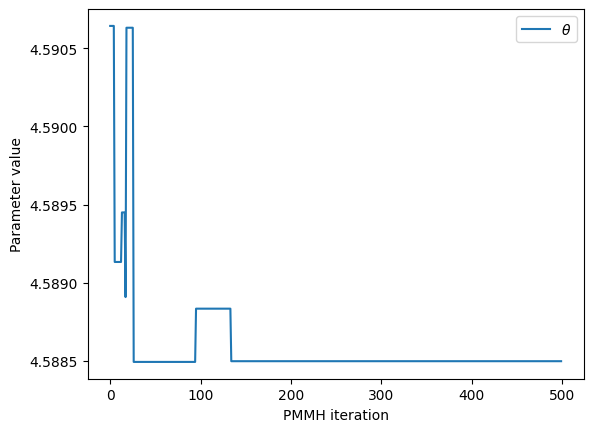

In [8]:
"""
PMMH test / debug run for benchmark model
"""

""" Test whether the PMMH sampling works by sampling
an intiial estimate from the posterior p(theta|y_1:T,temp)
"""

temp = 10 # Initial tempering
T = 50 # Number of observations

# True parameter
theta = 1

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
_, ys = SimpleBenchmarkSSM_simulate(theta=theta,T=T,us=us,rng=rng)

n_particles = 50
proposal_sd = 0.03

# Sample theta from parameter prior
theta = SimpleBenchmarkSSM_sample_prior()

# Generate particle approximations for p(y_t|x_1:T,theta,temp)
# for the initial parameter sample
t0 = time.time()
xs, aas, log_lik = SimpleBenchmarkSSM_bootstrap_pf(temp=temp,
                            n_particles=n_particles,
                            ys=ys,
                            us=us,
                            theta=theta,
                            alternative_tempering=False
                            )
t1 = time.time()
print(f'Particle filter took {t1 - t0}s')

# Run PMH
t0 = time.time()

samples, xss, aass, log_liks, accept_rate = SimpleBenchmarkSSM_pmmh(
    xs=xs,
    aas=aas,
    log_lik=log_lik,
    theta=theta,
    ys=ys,
    us=us,
    temp=temp,
    n_iters=500,
    proposal_sd=proposal_sd,
    verbose=True,
    alternative_tempering=False
)
t1 = time.time()
print(f'PMMH took {t1 - t0}s')
print(f'Acceptance rate of initial PMMH sample: {accept_rate}, sd: {proposal_sd}, particles: {n_particles}')

# Plot result
plt.plot(samples,label=r'$\theta$')
plt.xlabel('PMMH iteration')
plt.ylabel('Parameter value')
plt.legend()

In [31]:
""" Test whether SMC sampler works for the linear model
"""

temp = 10.0 # Initial tempering
T = 50 # Number of observations
                              
theta = np.asarray([0.8,-1.0]) # True parameter                              

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
_, ys = Svensson2017LinearSSM_simulate(T=T,theta=theta,u=us,rng=rng)

samples, records = Svensson2017LinearSSM_smc(
    ys=ys,
    us=us,
    initial_mh_iters=300,
    initial_mh_sd=0.4,
    mh_iters=40,
    mh_sd=0.02,
    n_sample_particles=25,
    n_filter_particles=50,
    temp=temp,
    min_temp=0.05,
    alpha=0.1,
    verbose=True,
    alternative_tempering=False,
    adaptive_pmh=True
)

New iteration: p = 1
Starting bisection...
Updated temperature, new temperature is: 2.616448974609375
Bisection took 0.8606293201446533s
Starting mutation...
Finished mutation. Mutation took 19.46832036972046s
Mean accept rate: 0.433
New iteration: p = 2
Starting bisection...
Updated temperature, new temperature is: 1.9948871135711668
Bisection took 0.12635135650634766s
Starting mutation...
Finished mutation. Mutation took 0.2005305290222168s
Mean accept rate: 0.5009999999999999
New iteration: p = 3
Starting bisection...
Updated temperature, new temperature is: 1.6796026791445908
Bisection took 0.15146231651306152s
Starting mutation...
Finished mutation. Mutation took 0.19982481002807617s
Mean accept rate: 0.35700000000000004
New iteration: p = 4
Starting bisection...
Updated temperature, new temperature is: 1.541150107771955
Bisection took 0.1644737720489502s
Starting mutation...
Finished mutation. Mutation took 0.2151496410369873s
Mean accept rate: 0.331
New iteration: p = 5
Starting

In [ ]:
""" Test whether SMC sampler works for the nonlinear model
"""

temp = 1.0 # Initial tempering
T = 200 # Number of observations
                              
theta = np.asarray([1,1]) # True parameter                              

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
_, ys = Svensson2017NonLinearSSM_simulate(T=T,theta=theta,u=us,rng=rng)

samples, records = Svensson2017NonLinearSSM_smc(
    ys=ys,
    us=us,
    initial_mh_iters=300,
    initial_mh_sd=0.4,
    mh_iters=40,
    mh_sd=0.02,
    n_sample_particles=100,
    n_filter_particles=300,
    temp=temp,
    min_temp=0.05,
    alpha=0.4,
    verbose=True,
    alternative_tempering=False,
    adaptive_pmh=False
)

New iteration: p = 1
Starting bisection...
Updated temperature, new temperature is: 9.639567565917968
Bisection took 1.9466938972473145s
Starting mutation...
Finished mutation. Mutation took 19.57998490333557s
Mean accept rate: 0.83
New iteration: p = 2
Starting bisection...
Updated temperature, new temperature is: 9.216248795040881
Bisection took 1.0858981609344482s
Starting mutation...
Finished mutation. Mutation took 2.7830657958984375s
Mean accept rate: 0.5535000000000001
New iteration: p = 3
Starting bisection...
Updated temperature, new temperature is: 8.773433492228696
Bisection took 1.026684045791626s
Starting mutation...
Finished mutation. Mutation took 3.054988384246826s
Mean accept rate: 0.4010000000000001
New iteration: p = 4
Starting bisection...
Updated temperature, new temperature is: 8.424687829544993
Bisection took 0.9789807796478271s
Starting mutation...
Finished mutation. Mutation took 2.873047113418579s
Mean accept rate: 0.44925
New iteration: p = 5
Starting bisecti

KeyboardInterrupt: 

In [6]:
""" Test whether SMC sampler works for the benchmark model
"""

temp = 1.0 # Initial tempering
T = 50 # Number of observations
                              
theta = 1.4 # True parameter                              

n_filter_particles = 50
n_sample_particles = 100

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T) 

# Sample observations from true state-space model
_, ys = SimpleBenchmarkSSM_simulate(T=T,theta=theta,us=us,rng=rng)

samples, records = SimpleBenchmarkSSM_smc(
    ys=ys,
    us=us,
    initial_mh_iters=100,
    initial_mh_sd=0.5,
    mh_iters=40,
    mh_sd=0.02,
    n_sample_particles=n_sample_particles,
    n_filter_particles=n_filter_particles,
    temp=temp,
    min_temp=0.01,
    alpha=0.5,
    verbose=True,
    alternative_tempering=True,
    adaptive_pmh=True
)

New iteration: p = 1
Starting bisection...
Updated temperature, new temperature is: 0.9999996975809335
Bisection took 0.07976078987121582s
Starting mutation...
Finished mutation. Mutation took 0.1152791976928711s
Mean accept rate: 0.5355
New iteration: p = 2
Starting bisection...
Updated temperature, new temperature is: 0.9998972586855293
Bisection took 0.07471871376037598s
Starting mutation...
Finished mutation. Mutation took 0.1320023536682129s
Mean accept rate: 0.6547499999999999
New iteration: p = 3
Starting bisection...
Updated temperature, new temperature is: 0.9992038616055803
Bisection took 0.08142828941345215s
Starting mutation...
Finished mutation. Mutation took 0.12307000160217285s
Mean accept rate: 0.6164999999999999
New iteration: p = 4
Starting bisection...
Updated temperature, new temperature is: 0.9976392686676598
Bisection took 0.08290791511535645s
Starting mutation...
Finished mutation. Mutation took 0.12905502319335938s
Mean accept rate: 0.26625
New iteration: p = 5


In [7]:
""" Save the latest record """

print(records)

df = pd.DataFrame.from_dict(records, orient="index")
df.to_csv("results/benchmark.csv")

{0: {'temp': 1.0, 'particles': array([-1.37529869e+00,  1.18659473e+00,  2.57595424e+00, -3.04294667e+00,
        1.42108049e+00,  1.79804168e+00, -2.82048481e+00, -1.86927988e-01,
       -2.59645411e+00, -4.71480206e+00, -1.24781241e+00,  3.08662796e+00,
       -3.48654051e+00,  1.80018608e+00,  4.53327530e+00, -3.52636262e+00,
       -3.94612295e+00,  2.93056627e+00,  9.04816580e-01,  9.19060087e-01,
       -1.20520325e+00, -2.94874627e+00, -3.24524875e+00, -4.57397666e+00,
        2.58501873e+00, -4.53698600e+00, -1.12145297e+00, -8.33247943e-01,
       -2.13039811e+00, -1.51377820e-01, -3.36337859e-03,  2.20101774e+00,
        6.76546879e-01, -1.61152471e+00,  2.23820526e+00,  3.78011832e+00,
       -3.72745664e+00, -1.22159353e+00, -4.48585759e+00,  2.00495296e+00,
        2.05115796e+00,  4.56693725e+00,  1.75414117e+00, -2.03525607e+00,
        1.49799504e+00,  8.25059012e-01, -1.05677954e+00, -3.07450288e+00,
       -9.31427277e-02,  3.88503021e+00, -1.96049500e+00,  4.19999173

In [4]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter

def animate_particle_histograms(
    records,
    true_param=1.0,
    bins=40,
    interval=120,
    save_path=None,
):
    """
    records: dict[int, dict] or list[dict]
      Each record should contain:
        - 'temp'
        - 'particles'
        - optionally 'log_likelihoods'
        - optionally 'accept_rate'
    """

    # Normalize input
    if isinstance(records, dict):
        items = sorted(records.items(), key=lambda kv: kv[1]["temp"], reverse=True)
        steps = [k for k, _ in items]
        frames = [v for _, v in items]
    else:
        steps = list(range(len(records)))
        frames = sorted(records, key=lambda r: r["temp"], reverse=True)

    all_particles = np.concatenate([np.asarray(r["particles"]) for r in frames])
    x_min, x_max = np.percentile(all_particles, [0.5, 99.5])

    # Include true parameter even if far away
    x_min = min(x_min, true_param)
    x_max = max(x_max, true_param)

    pad = 0.08 * (x_max - x_min)
    x_min -= pad
    x_max += pad

    bin_edges = np.linspace(x_min, x_max, bins + 1)

    fig, ax = plt.subplots(figsize=(9, 5.5))

    def draw(i):
        ax.clear()

        r = frames[i]
        particles = np.asarray(r["particles"])
        temp = r["temp"]
        accept_rate = r.get("accept_rate", None)

        ax.hist(
            particles,
            bins=bin_edges,
            density=True,
            alpha=0.75,
            edgecolor="black",
            linewidth=0.6,
        )

        ax.axvline(true_param, linestyle="--", linewidth=2.5, label=f"true parameter = {true_param}")
        ax.axvline(np.mean(particles), linestyle="-", linewidth=2, label=f"particle mean = {np.mean(particles):.3g}")

        ax.set_xlim(x_min, x_max)
        ax.set_xlabel("Particle value")
        ax.set_ylabel("Density")

        title = f"Particle filter histogram | step {steps[i]} | temp = {temp:.4f}"
        if accept_rate is not None:
            title += f" | accept rate = {accept_rate:.3f}"
        ax.set_title(title)

        ax.legend(loc="upper right")
        ax.grid(alpha=0.25)

        fig.tight_layout()

    anim = FuncAnimation(fig, draw, frames=len(frames), interval=interval, repeat=True)

    if save_path:
        if save_path.endswith(".gif"):
            anim.save(save_path, writer=PillowWriter(fps=1000 // interval))
        elif save_path.endswith(".mp4"):
            anim.save(save_path, writer=FFMpegWriter(fps=1000 // interval))
        else:
            raise ValueError("save_path must end with .gif or .mp4")

    return anim


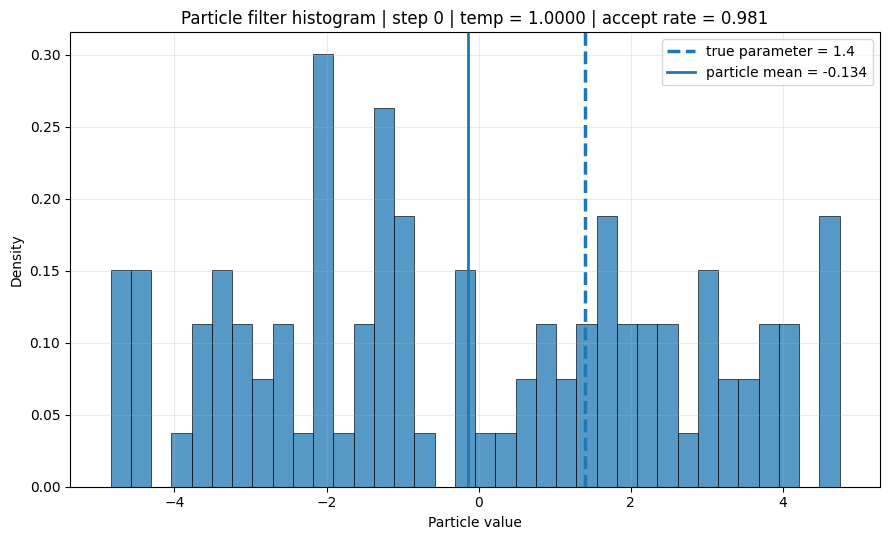

In [8]:
from IPython.display import HTML

anim = animate_particle_histograms(records, true_param=theta)
HTML(anim.to_jshtml())

In [21]:
""" Piece of code for estimating the variance of
a particle filter likelihood estimate at a given parameter value
"""

@njit
def likelihood_variance_estimate(temp, n_particles, ys, us, theta, n_repeats=100):
    """ Estimates the variance of the bootstrap particle filter
    likelihood estimate for given parameters.
    
    Parameters
    -
    Params for input to particle filter
    -
    temp        : float
                  tempering parameter
    n_particles : int
                  number of particles to use
    ys          : ndarray of shape (T,)
                  List of observations from the 
                  underlying state-space model
    us          : ndarray of shape (T,)
                  List of exogenous input parameters
                  in the underlying state-space model
    theta       : ndarray of shape (2,)
                  Parameters of the underlying state-space
                  model
    -
    Params for variance estimation
    -
    n_repeat    : int, default=100
                  Number of times to re-run the particle filter
                  for variance estimation
                  
    Returns
    -
    var         : float
                  Empirical variance of log-likelihood estimate
    log_liks    : ndarray of shape (n_repeats,)
                  List of log-likelihoods obtained from repeated particle filtering
    """
    log_liks = np.zeros(n_repeats)
    for r in range(n_repeats):
        _, _, log_lik = SimpleBenchmarkSSM_bootstrap_pf(temp, n_particles, ys, us, theta)
        log_liks[r] = log_lik
    var = np.var(log_liks)
    return var, log_liks



@njit(parallel=True)
def estimate_variances_parallel(temp, n_particles, ys, us, thetas, n_repeats):
    n_samples = thetas.shape[0]
    vars = np.empty(n_samples, dtype=np.float64)
    for m in prange(n_samples):
        vars[m], _ = likelihood_variance_estimate(temp, n_particles, ys, us, thetas[m], n_repeats)
    return np.mean(vars), np.std(vars)



""" Save the latest record """

df = pd.DataFrame.from_dict(records, orient="index")
df.to_csv("results/benchmark.csv")


""" Load a record """

df = pd.read_csv('results/smc_records_thisone.csv')

# For some reason, 'particles' column contains strings
# So quick fix here
def parse_particles(s):
    s = s.strip().replace("[", " ").replace("]", " ")
    return np.fromstring(s, sep=" ", dtype=np.float64)

df["particles"] = df["particles"].apply(parse_particles)

n_particles = len(df["particles"].iloc[0]) # Number of particles

# Loop over temperatures and particles
iter_delay = 5
temps_evaluated = []
means_of_vars = []
stds_of_vars = []
particle_means = []
for temp, particles in zip(df["temp"][::iter_delay],df["particles"][::iter_delay]):
    print(f"Computing variances; temp={temp}")

    mean_var, std_var = estimate_variances_parallel(temp, n_filter_particles, ys, us, particles, n_repeats=15)

    temps_evaluated.append(temp)
    means_of_vars.append(mean_var)
    stds_of_vars.append(std_var)
    particle_means.append(np.mean(particles,axis=0))

    print(f"Mean of variances: {mean_var}")

# Convert to numpy
temps_evaluated = np.array(temps_evaluated)
means_of_vars = np.array(means_of_vars)
stds_of_vars = np.array(stds_of_vars)
particle_means = np.array(particle_means)

Computing variances; temp=10.0
Mean of variances: 5.232925905968673e+41
Computing variances; temp=8.089205178129042
Mean of variances: 1.4271958100665896e+34
Computing variances; temp=6.584221830276414
Mean of variances: 4.876130355724439e+34
Computing variances; temp=5.535461947870831
Mean of variances: 3.4858430245751305e+33
Computing variances; temp=4.760250521213651
Mean of variances: 5.024506342571866e+30
Computing variances; temp=4.200541570153542
Mean of variances: 2.687419584109703e+34
Computing variances; temp=3.7013549942757846
Mean of variances: 6.275373878625618e+36
Computing variances; temp=3.2985890273620218
Mean of variances: 2.0620929082062456e+28
Computing variances; temp=2.9981783054227207
Mean of variances: 5.657021175170915e+32
Computing variances; temp=2.7451987427107967
Mean of variances: 2.3871529872416503e+38
Computing variances; temp=2.529275828645687
Mean of variances: 4.690899804068052e+40
Computing variances; temp=2.3321014859532694
Mean of variances: 4.5384